In [1]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [4]:
from sklearn.datasets import load_digits
digits = load_digits()

In [9]:
import pandas as pd

df = pd.DataFrame(digits.data)
df['target'] = digits.target

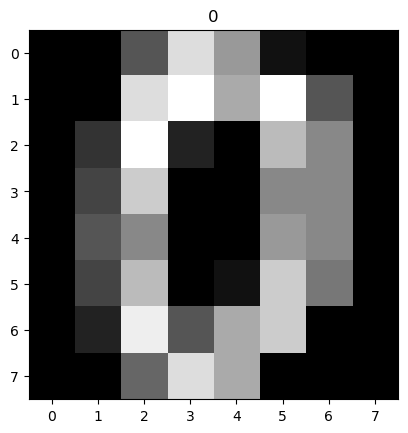

In [10]:
import matplotlib.pyplot as plt

plt.imshow(digits.images[0], cmap = 'gray')
plt.title(digits.target[0])
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size = 0.4)

In [12]:
model = svm.SVC(kernel = 'rbf', C = 30, gamma = 'auto')
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.47426981919332406

In [13]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma = 'auto'),
        'params' : {
            'C': [1, 10, 20],
            'kernel': ['rbf', 'linear']
        }
    },

    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'n_estimators': [1, 5, 10]
        }
    },

    'logistic_regression' : {
        'model': LogisticRegression(solver = 'liblinear', multi_class = 'auto'),
        'params': {
            'C': [1, 5, 10]
        }
    },

    'gaussian_nb' : {
        'model': GaussianNB(),
        'params': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]

        }
    },

    'multinomial_nb' : {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0]
        }
    },

    'decision_tree' : {
        'model': DecisionTreeClassifier(),
        'params': {
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
}

In [15]:
from sklearn.model_selection import GridSearchCV

clf = GridSearchCV(svm.SVC(gamma = 'auto'), {
    'C': [1, 10, 20],
    'kernel': ['rbf', 'linear']
}, cv = 5, return_train_score = False)

clf.fit(digits.data, digits.target)
clf.cv_results_

{'mean_fit_time': array([0.13358965, 0.01559649, 0.12840018, 0.01480522, 0.12905483,
        0.01479974]),
 'std_fit_time': array([0.00312792, 0.00079887, 0.00185491, 0.0007478 , 0.00071932,
        0.00097644]),
 'mean_score_time': array([0.0413981 , 0.00380273, 0.03999872, 0.00359507, 0.04060102,
        0.00400009]),
 'std_score_time': array([1.35453482e-03, 3.97905806e-04, 3.44974465e-06, 4.90140551e-04,
        8.01931160e-04, 4.25588851e-06]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear'],
              mask=[False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'C': 1, 'kernel': 'rbf'},
  {'C': 1, 'kernel': 'linear'},
  {'C': 10, 'kernel': 'rbf'},
  {'C': 10, 'kernel': 'linear'},
  {'C': 20, 'kernel': 'rbf'},
  {'C': 20, 'kernel': 'linear'}],


In [16]:
scores = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv = 5, return_train_score = False)
    clf.fit(digits.data, digits.target)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in versio

In [24]:
df = pd.DataFrame(scores, columns = ['model', 'best_score', 'best_params'])
pd.set_option('display.max_colwidth', None)

df = df.sort_values(by = "best_score", ascending = False)

df

,model,best_score,best_params
0,svm,0.947697,"{'C': 1, 'kernel': 'linear'}"
2,logistic_regression,0.922114,{'C': 1}
1,random_forest,0.905422,{'n_estimators': 10}
4,multinomial_nb,0.870907,{'alpha': 0.1}
3,gaussian_nb,0.838635,{'var_smoothing': 1e-06}
5,decision_tree,0.790245,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}"
